In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, make_scorer, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import pickle

In [2]:
def view_continuous(df,column,bins=30):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    # Boxplot
    axes[0].boxplot(df[column])
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Value')
    axes[0].set_title('Boxplot')

    # Histogram
    axes[1].hist(df[column], bins=bins, color='skyblue', edgecolor='black')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Histogram')
    
    # Boxplot
    axes[2].boxplot([df[df['Diabetes_012'] == 0][column], df[df['Diabetes_012'] == 1][column], df[df['Diabetes_012'] == 2][column]], tick_labels=['Non-Diabetic', 'Prediabetic', 'Diabetic'])
    axes[2].set_xlabel(column)
    axes[2].set_ylabel('Value')
    axes[2].set_title('Boxplot')

    # Stacked Histogram
    axes[3].hist([df[df['Diabetes_012'] == 0][column], df[df['Diabetes_012'] == 1][column], df[df['Diabetes_012'] == 2][column]], 
                 bins=bins, alpha=0.7, label=['Non-Diabetic', 'Prediabetic', 'Diabetic'], stacked=True, color=['skyblue','red','green'], edgecolor='black')
    axes[3].set_xlabel(column)
    axes[3].set_ylabel('Frequency')
    axes[3].set_title('Histogram')

    
    
    plt.tight_layout()
    plt.legend(['Non-Diabetic', 'Prediabetic', 'Diabetic'])
    plt.show()

In [2]:
df = pd.read_csv("Phase 2 data.csv")

In [3]:
df = df.drop('Index',axis=1)

In [5]:
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,0.0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1,0.0,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,0.0,...,0,1,1,0,0,0,0,0,0,0
2,0.0,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1
3,0.0,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,0.0,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,1,0
253676,2.0,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,0.0,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,1.0,...,1,0,0,1,0,0,0,0,0,0
253678,0.0,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,1.0,...,1,0,1,0,0,0,0,0,0,0


Set up k-fold cross validation

In [4]:
kf = KFold(n_splits=10)

In [5]:
def generic_validator(model, X, y, kf):
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []
    aucs = []

    accuracies_final = []
    precisions_final = []
    recalls_final = []
    f1_scores_final = []
    auc_final = []

    for i in range (0,3):
        accuracies_final.append(0.0)
        precisions_final.append(0.0)
        recalls_final.append(0.0)
        f1_scores_final.append(0.0)
        auc_final.append(0.0)
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train,Y_train)
        Y_pred = model.predict(X_test)
        Y_pred_proba = model.predict_proba(X_test)

        accuracies.append(accuracy_score(Y_test,Y_pred))
        precisions.append(precision_score(Y_test,Y_pred,average=None))
        recalls.append(recall_score(Y_test,Y_pred,average=None))
        f1_scores.append(f1_score(Y_test,Y_pred,average=None))
        aucs.append(roc_auc_score(Y_test,Y_pred_proba, average=None,multi_class='ovr'))
    
    for i in range (0,10):
        accuracies_final = np.add(accuracies_final,accuracies[i])
        precisions_final = np.add(precisions_final,precisions[i])
        recalls_final = np.add(recalls_final,recalls[i])
        f1_scores_final = np.add(f1_scores_final,f1_scores[i])
        auc_final = np.add(auc_final,aucs[i])

    for i in range (0,3):
        accuracies_final[i] = accuracies_final[i]/10.0
        precisions_final[i] = precisions_final[i]/10.0
        recalls_final[i] = recalls_final[i]/10.0
        f1_scores_final[i] = f1_scores_final[i]/10.0
        auc_final[i] = auc_final[i]/10.0

    data = {
        'Digit': [0,1,2],
        'Accuracy': accuracies_final,
        'Precision': precisions_final,
        'Recall': recalls_final,
        'F-measure': f1_scores_final,
        'AUC': auc_final
    }

    results_df = pd.DataFrame(data)
    
    return results_df, accuracies, precisions, recalls, f1_scores, aucs

# KNN

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In order to run knn, all values must be normalized. Everything is boolean except for BMI, so it has to be normalized

Also ignore knn_log_n in the normalized run since it is identical to log_square_n

In [7]:
df_knn = df.copy()

In [8]:
df_knn["BMI"] = (df_knn["BMI"] - df_knn["BMI"].min()) / (df_knn["BMI"].max() - df_knn["BMI"].min())

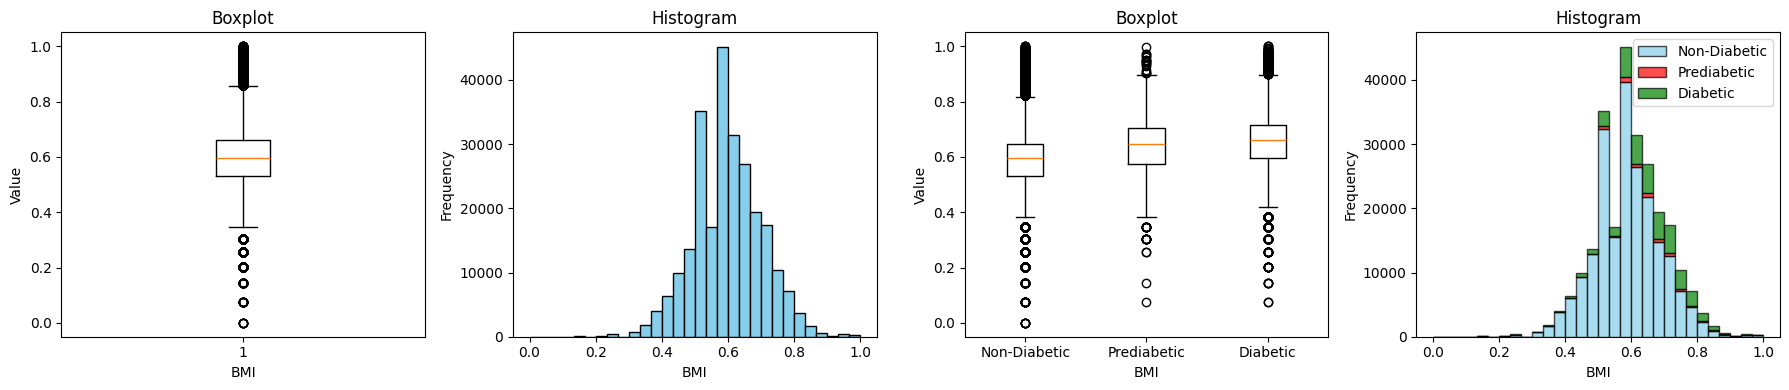

In [23]:
view_continuous(df_knn,'BMI')

Now we can run KNN

In [9]:
X = df_knn.iloc[:, 1:]
y = df_knn['Diabetes_012']

In [10]:
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,1.0,1.0,1.0,0.767962,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
1,0.0,0.0,0.0,0.553213,1.0,0.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.612990,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,1.0,0.0,1.0,0.594418,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,1.0,1.0,0.530267,0.0,0.0,0.0,1.0,1.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1.0,1.0,1.0,0.809649,0.0,0.0,0.0,0.0,1.0,1.0,...,0,1,0,0,0,0,0,0,1,0
253676,1.0,1.0,1.0,0.344895,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,0.0,0.0,1.0,0.612990,0.0,0.0,0.0,1.0,1.0,0.0,...,1,0,0,1,0,0,0,0,0,0
253678,1.0,0.0,1.0,0.505508,0.0,0.0,0.0,0.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,0


In [11]:
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [25]:
math.sqrt(len(df_knn))

503.66655636442647

In [26]:
math.log2(len(df_knn))

17.952650256991202

In [11]:
accuracies_root_n = []
accuracies_log_n = []
accuracies_243_n = []
accuracies_300_n = []
accuracies_200_n = []

precisions_root_n = []
precisions_log_n = []
precisions_243_n = []
precisions_300_n = []
precisions_200_n = []

recalls_root_n = []
recalls_log_n = []
recalls_243_n = []
recalls_300_n = []
recalls_200_n = []

f1_scores_root_n = []
f1_scores_log_n = []
f1_scores_243_n = []
f1_scores_300_n = []
f1_scores_200_n = []

auc_root_n = []
auc_log_n = []
auc_243_n = []
auc_300_n = []
auc_200_n = []
    


In [13]:
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    knn_root_n.fit(X_train,Y_train)
    knn_log_n.fit(X_train,Y_train)
    knn_243_n.fit(X_train,Y_train)
    knn_300_n.fit(X_train,Y_train)
    knn_200_n.fit(X_train,Y_train)
    
    Y_pred_root_n = knn_root_n.predict(X_test)
    Y_pred_proba_root_n = knn_root_n.predict_proba(X_test)

    Y_pred_log_n = knn_log_n.predict(X_test)
    Y_pred_proba_log_n = knn_log_n.predict_proba(X_test)

    Y_pred_243_n = knn_243_n.predict(X_test)
    Y_pred_proba_243_n = knn_243_n.predict_proba(X_test)

    Y_pred_300_n = knn_300_n.predict(X_test)
    Y_pred_proba_300_n = knn_300_n.predict_proba(X_test)

    Y_pred_200_n = knn_200_n.predict(X_test)
    Y_pred_proba_200_n = knn_200_n.predict_proba(X_test)

    accuracies_root_n.append(accuracy_score(Y_test,Y_pred_root_n))
    precisions_root_n.append(precision_score(Y_test,Y_pred_root_n,average=None))
    recalls_root_n.append(recall_score(Y_test,Y_pred_root_n,average=None))
    f1_scores_root_n.append(f1_score(Y_test,Y_pred_root_n,average=None))
    auc_root_n.append(roc_auc_score(Y_test,Y_pred_proba_root_n, average=None,multi_class='ovr'))

    accuracies_log_n.append(accuracy_score(Y_test,Y_pred_log_n))
    precisions_log_n.append(precision_score(Y_test,Y_pred_log_n,average=None))
    recalls_log_n.append(recall_score(Y_test,Y_pred_log_n,average=None))
    f1_scores_log_n.append(f1_score(Y_test,Y_pred_log_n,average=None))
    auc_log_n.append(roc_auc_score(Y_test,Y_pred_proba_log_n, average=None,multi_class='ovr'))

    accuracies_243_n.append(accuracy_score(Y_test,Y_pred_243_n))
    precisions_243_n.append(precision_score(Y_test,Y_pred_243_n,average=None))
    recalls_243_n.append(recall_score(Y_test,Y_pred_243_n,average=None))
    f1_scores_243_n.append(f1_score(Y_test,Y_pred_243_n,average=None))
    auc_243_n.append(roc_auc_score(Y_test,Y_pred_proba_243_n, average=None,multi_class='ovr'))

    accuracies_300_n.append(accuracy_score(Y_test,Y_pred_300_n))
    precisions_300_n.append(precision_score(Y_test,Y_pred_300_n,average=None))
    recalls_300_n.append(recall_score(Y_test,Y_pred_300_n,average=None))
    f1_scores_300_n.append(f1_score(Y_test,Y_pred_300_n,average=None))
    auc_300_n.append(roc_auc_score(Y_test,Y_pred_proba_300_n, average=None,multi_class='ovr'))

    accuracies_200_n.append(accuracy_score(Y_test,Y_pred_200_n))
    precisions_200_n.append(precision_score(Y_test,Y_pred_200_n,average=None))
    recalls_200_n.append(recall_score(Y_test,Y_pred_200_n,average=None))
    f1_scores_200_n.append(f1_score(Y_test,Y_pred_200_n,average=None))
    auc_200_n.append(roc_auc_score(Y_test,Y_pred_proba_200_n, average=None,multi_class='ovr'))

c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [72]:
accuracies_final_root_n = []
precisions_final_root_n = []
recalls_final_root_n = []
f1_scores_final_root_n = []
auc_final_root_n = []

accuracies_final_log_n = []
precisions_final_log_n = []
recalls_final_log_n = []
f1_scores_final_log_n = []
auc_final_log_n = []

accuracies_final_243_n = []
precisions_final_243_n = []
recalls_final_243_n = []
f1_scores_final_243_n = []
auc_final_243_n = []

accuracies_final_300_n = []
precisions_final_300_n = []
recalls_final_300_n = []
f1_scores_final_300_n = []
auc_final_300_n = []

accuracies_final_200_n = []
precisions_final_200_n = []
recalls_final_200_n = []
f1_scores_final_200_n = []
auc_final_200_n = []

In [73]:
for i in range (0,3):
    accuracies_final_root_n.append(0.0)
    precisions_final_root_n.append(0.0)
    recalls_final_root_n.append(0.0)
    f1_scores_final_root_n.append(0.0)
    auc_final_root_n.append(0.0)

    accuracies_final_log_n.append(0.0)
    precisions_final_log_n.append(0.0)
    recalls_final_log_n.append(0.0)
    f1_scores_final_log_n.append(0.0)
    auc_final_log_n.append(0.0)

    accuracies_final_243_n.append(0.0)
    precisions_final_243_n.append(0.0)
    recalls_final_243_n.append(0.0)
    f1_scores_final_243_n.append(0.0)
    auc_final_243_n.append(0.0)

    accuracies_final_300_n.append(0.0)
    precisions_final_300_n.append(0.0)
    recalls_final_300_n.append(0.0)
    f1_scores_final_300_n.append(0.0)
    auc_final_300_n.append(0.0)

    accuracies_final_200_n.append(0.0)
    precisions_final_200_n.append(0.0)
    recalls_final_200_n.append(0.0)
    f1_scores_final_200_n.append(0.0)
    auc_final_200_n.append(0.0)

In [64]:
precisions_root_n[9]

array([0.84251281, 0.        , 0.68648649])

In [63]:
np.add([1,2,3],precisions_root_n[0])

array([1.84177064, 2.        , 3.67821782])

In [74]:
for i in range (0,10):
    accuracies_final_root_n = np.add(accuracies_final_root_n,accuracies_root_n[i])
    precisions_final_root_n = np.add(precisions_final_root_n,precisions_root_n[i])
    recalls_final_root_n = np.add(recalls_final_root_n,recalls_root_n[i])
    f1_scores_final_root_n = np.add(f1_scores_final_root_n,f1_scores_root_n[i])
    auc_final_root_n = np.add(auc_final_root_n,auc_root_n[i])

    accuracies_final_log_n = np.add(accuracies_final_log_n,accuracies_log_n[i])
    precisions_final_log_n = np.add(precisions_final_log_n,precisions_log_n[i])
    recalls_final_log_n = np.add(recalls_final_log_n,recalls_log_n[i])
    f1_scores_final_log_n = np.add(f1_scores_final_log_n,f1_scores_log_n[i])
    auc_final_log_n = np.add(auc_final_log_n,auc_log_n[i])

    accuracies_final_243_n = np.add(accuracies_final_243_n,accuracies_243_n[i])
    precisions_final_243_n = np.add(precisions_final_243_n,precisions_243_n[i])
    recalls_final_243_n = np.add(recalls_final_243_n,recalls_243_n[i])
    f1_scores_final_243_n = np.add(f1_scores_final_243_n,f1_scores_243_n[i])
    auc_final_243_n = np.add(auc_final_243_n,auc_243_n[i])

    accuracies_final_300_n = np.add(accuracies_final_300_n,accuracies_300_n[i])
    precisions_final_300_n = np.add(precisions_final_300_n,precisions_300_n[i])
    recalls_final_300_n = np.add(recalls_final_300_n,recalls_300_n[i])
    f1_scores_final_300_n = np.add(f1_scores_final_300_n,f1_scores_300_n[i])
    auc_final_300_n = np.add(auc_final_300_n,auc_300_n[i])

    accuracies_final_200_n = np.add(accuracies_final_200_n,accuracies_200_n[i])
    precisions_final_200_n = np.add(precisions_final_200_n,precisions_200_n[i])
    recalls_final_200_n = np.add(recalls_final_200_n,recalls_200_n[i])
    f1_scores_final_200_n = np.add(f1_scores_final_200_n,f1_scores_200_n[i])
    auc_final_200_n = np.add(auc_final_200_n,auc_200_n[i])



In [75]:
accuracies_final_root_n

array([8.44741406, 8.44741406, 8.44741406])

In [76]:
precisions_final_root_n

array([8.46190179, 0.        , 6.45995033])

In [77]:
for i in range (0,3):
    accuracies_final_root_n[i] = accuracies_final_root_n[i]/10.0
    precisions_final_root_n[i] = precisions_final_root_n[i]/10.0
    recalls_final_root_n[i] = recalls_final_root_n[i]/10.0
    f1_scores_final_root_n[i] = f1_scores_final_root_n[i]/10.0
    auc_final_root_n[i] = auc_final_root_n[i]/10.0

    accuracies_final_log_n[i] = accuracies_final_log_n[i]/10.0
    precisions_final_log_n[i] = precisions_final_log_n[i]/10.0
    recalls_final_log_n[i] = recalls_final_log_n[i]/10.0
    f1_scores_final_log_n[i] = f1_scores_final_log_n[i]/10.0
    auc_final_log_n[i] = auc_final_log_n[i]/10.0

    accuracies_final_243_n[i] = accuracies_final_243_n[i]/10.0
    precisions_final_243_n[i] = precisions_final_243_n[i]/10.0
    recalls_final_243_n[i] = recalls_final_243_n[i]/10.0
    f1_scores_final_243_n[i] = f1_scores_final_243_n[i]/10.0
    auc_final_243_n[i] = auc_final_243_n[i]/10.0

    accuracies_final_300_n[i] = accuracies_final_300_n[i]/10.0
    precisions_final_300_n[i] = precisions_final_300_n[i]/10.0
    recalls_final_300_n[i] = recalls_final_300_n[i]/10.0
    f1_scores_final_300_n[i] = f1_scores_final_300_n[i]/10.0
    auc_final_300_n[i] = auc_final_300_n[i]/10.0

    accuracies_final_200_n[i] = accuracies_final_200_n[i]/10.0
    precisions_final_200_n[i] = precisions_final_200_n[i]/10.0
    recalls_final_200_n[i] = recalls_final_200_n[i]/10.0
    f1_scores_final_200_n[i] = f1_scores_final_200_n[i]/10.0
    auc_final_200_n[i] = auc_final_200_n[i]/10.0

In [78]:
data_root_n = {
    'Label': [0,1,2],
    'Accuracy': accuracies_final_root_n,
    'Precision': precisions_final_root_n,
    'Recall': recalls_final_root_n,
    'F-measure': f1_scores_final_root_n,
    'AUC': auc_final_root_n
}

results_df_root_n = pd.DataFrame(data_root_n)

data_log_n = {
    'Label': [0,1,2],
    'Accuracy': accuracies_final_log_n,
    'Precision': precisions_final_log_n,
    'Recall': recalls_final_log_n,
    'F-measure': f1_scores_final_log_n,
    'AUC': auc_final_log_n
}

results_df_log_n = pd.DataFrame(data_log_n)

data_243_n = {
    'Label': [0,1,2],
    'Accuracy': accuracies_final_243_n,
    'Precision': precisions_final_243_n,
    'Recall': recalls_final_243_n,
    'F-measure': f1_scores_final_243_n,
    'AUC': auc_final_243_n
}

results_df_243_n = pd.DataFrame(data_243_n)

data_300_n = {
    'Label': [0,1,2],
    'Accuracy': accuracies_final_300_n,
    'Precision': precisions_final_300_n,
    'Recall': recalls_final_300_n,
    'F-measure': f1_scores_final_300_n,
    'AUC': auc_final_300_n
}

results_df_300_n = pd.DataFrame(data_300_n)

data_200_n = {
    'Label': [0,1,2],
    'Accuracy': accuracies_final_200_n,
    'Precision': precisions_final_200_n,
    'Recall': recalls_final_200_n,
    'F-measure': f1_scores_final_200_n,
    'AUC': auc_final_200_n
}

results_df_200_n = pd.DataFrame(data_200_n)

In [79]:
results_df_root_n

,Label,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.844741,0.846190,0.997171,0.915489,0.808610
1,1,0.844741,0.000000,0.000000,0.000000,0.678906
2,2,0.844741,0.645995,0.033648,0.063914,0.813480


In [80]:
results_df_log_n

,Label,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.844741,0.846190,0.997171,0.915489,0.808610
1,1,0.844741,0.000000,0.000000,0.000000,0.678906
2,2,0.844741,0.645995,0.033648,0.063914,0.813480


In [82]:
results_df_243_n

,Label,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.845211,0.847837,0.995233,0.915633,0.808602
1,1,0.845211,0.000000,0.000000,0.000000,0.662508
2,2,0.845211,0.610618,0.048648,0.090027,0.813519


In [83]:
results_df_300_n

,Label,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.845191,0.847375,0.995935,0.915661,0.808649
1,1,0.845191,0.000000,0.000000,0.000000,0.666267
2,2,0.845191,0.626470,0.044304,0.082685,0.813505


In [84]:
results_df_200_n

,Label,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.845463,0.848388,0.994764,0.915757,0.808380
1,1,0.845463,0.000000,0.000000,0.000000,0.657593
2,2,0.845463,0.608838,0.053295,0.097921,0.813272


In [35]:
knn_root_n = KNeighborsClassifier(n_neighbors=math.floor(math.sqrt(len(df_knn))))
knn_root_n.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=503)

In [ ]:
knn_log_n = KNeighborsClassifier(n_neighbors=math.floor(math.log2(len(df_knn))))
knn_log_n.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=503)

In [47]:
knn_mid_1 = KNeighborsClassifier(n_neighbors=243)
knn_mid_1.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=243)

In [10]:
knn_mid_2 = KNeighborsClassifier(n_neighbors=300)
knn_mid_2.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=300)

In [14]:
knn_mid_3 = KNeighborsClassifier(n_neighbors=200)
knn_mid_3.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=200)

In [29]:
with open('knn_log_n.pkl','wb') as f:
    pickle.dump(knn_log_n,f)

In [37]:
y_pred_knn = knn_root_n.predict(X_test)
y_pred_proba_knn = knn_root_n.predict_proba(X_test)

In [40]:
auc=roc_auc_score(y_test,y_pred_proba_knn, average=None,multi_class='ovr')
auc

array([0.80675992, 0.68113121, 0.80978009])

In [42]:
print(classification_report(y_test,y_pred_knn,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     53428
           1       0.00      0.00      0.00      1125
           2       0.62      0.03      0.06      8867

    accuracy                           0.84     63420
   macro avg       0.49      0.34      0.33     63420
weighted avg       0.80      0.84      0.78     63420



c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [43]:
y_pred_log = knn_log_n.predict(X_test)
y_pred_proba_log = knn_log_n.predict_proba(X_test)

In [44]:
auc=roc_auc_score(y_test,y_pred_proba_knn, average=None,multi_class='ovr')
auc

array([0.80675992, 0.68113121, 0.80978009])

In [46]:
print(classification_report(y_test,y_pred_log,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     53428
           1       0.00      0.00      0.00      1125
           2       0.62      0.03      0.06      8867

    accuracy                           0.84     63420
   macro avg       0.49      0.34      0.33     63420
weighted avg       0.80      0.84      0.78     63420



c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [48]:
y_pred_mid_1 = knn_mid_1.predict(X_test)
y_pred_proba_mid_1 = knn_mid_1.predict_proba(X_test)

In [49]:
auc=roc_auc_score(y_test,y_pred_proba_mid_1, average=None,multi_class='ovr')
auc

array([0.80641585, 0.66332647, 0.80931157])

In [50]:
print(classification_report(y_test,y_pred_mid_1,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     53428
           1       0.00      0.00      0.00      1125
           2       0.61      0.05      0.09      8867

    accuracy                           0.85     63420
   macro avg       0.49      0.35      0.34     63420
weighted avg       0.80      0.85      0.78     63420



c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [11]:
y_pred_mid_2 = knn_mid_2.predict(X_test)
y_pred_proba_mid_2 = knn_mid_2.predict_proba(X_test)

In [12]:
auc=roc_auc_score(y_test,y_pred_proba_mid_2, average=None,multi_class='ovr')
auc

array([0.80758318, 0.66459924, 0.81236183])

In [13]:
print(classification_report(y_test,y_pred_mid_2,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     53485
           1       0.00      0.00      0.00      1127
           2       0.63      0.04      0.08      8808

    accuracy                           0.85     63420
   macro avg       0.49      0.35      0.33     63420
weighted avg       0.80      0.85      0.78     63420



c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [15]:
y_pred_mid_3 = knn_mid_3.predict(X_test)
y_pred_proba_mid_3 = knn_mid_3.predict_proba(X_test)

In [16]:
auc=roc_auc_score(y_test,y_pred_proba_mid_3, average=None,multi_class='ovr')
auc

array([0.80757323, 0.65281038, 0.81236685])

In [17]:
print(classification_report(y_test,y_pred_mid_3,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     53485
           1       0.00      0.00      0.00      1127
           2       0.62      0.05      0.09      8808

    accuracy                           0.85     63420
   macro avg       0.49      0.35      0.34     63420
weighted avg       0.80      0.85      0.79     63420



c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Ignore the normalization this time since it can negatively impact results

Additionally, use the generalized function

In [10]:
X = df.iloc[:, 1:]
y = df['Diabetes_012']

In [ ]:
knn_root_n = KNeighborsClassifier(n_neighbors=math.floor(math.sqrt(len(df))))
knn_log_n = KNeighborsClassifier(n_neighbors=math.floor(math.log2(len(df))))
knn_243_n = KNeighborsClassifier(n_neighbors=243)
knn_300_n = KNeighborsClassifier(n_neighbors=300)
knn_200_n = KNeighborsClassifier(n_neighbors=200)

In [12]:
results_root_n, accuracies_root_n, precisions_root_n, recalls_root_n, f1_scores_root_n, aucs_root_n = generic_validator(knn_root_n, X, y, kf)
results_log_n, accuracies_log_n, precisions_log_n, recalls_log_n, f1_scores_log_n, aucs_log_n = generic_validator(knn_log_n, X, y, kf)
results_243_n, accuracies_243_n, precisions_243_n, recalls_243_n, f1_scores_243_n, aucs_243_n = generic_validator(knn_243_n, X, y, kf)
results_300_n, accuracies_300_n, precisions_300_n, recalls_300_n, f1_scores_300_n, aucs_300_n = generic_validator(knn_300_n, X, y, kf)
results_200_n, accuracies_200_n, precisions_200_n, recalls_200_n, f1_scores_200_n, aucs_200_n = generic_validator(knn_200_n, X, y, kf)

c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [13]:
results_root_n

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.846811,0.849974,0.994183,0.916434,0.815066
1,1,0.846811,0.000000,0.000000,0.000000,0.685367
2,2,0.846811,0.635289,0.066438,0.120152,0.819735


In [12]:
results_log_n

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.844071,0.859228,0.976942,0.914308,0.782921
1,1,0.844071,0.000000,0.000000,0.000000,0.557322
2,2,0.844071,0.499373,0.150917,0.231678,0.785173


In [15]:
results_243_n

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.847481,0.851727,0.992395,0.916690,0.814842
1,1,0.847481,0.000000,0.000000,0.000000,0.670096
2,2,0.847481,0.621830,0.082013,0.144749,0.819526


In [16]:
results_300_n

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.847264,0.851165,0.992943,0.916597,0.815144
1,1,0.847264,0.000000,0.000000,0.000000,0.674235
2,2,0.847264,0.626205,0.077183,0.137267,0.819733


In [17]:
results_200_n

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.84741,0.852100,0.991745,0.916628,0.814466
1,1,0.84741,0.000000,0.000000,0.000000,0.665359
2,2,0.84741,0.611412,0.085447,0.149799,0.819074


# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

In [96]:
X = df.iloc[:, 1:]
y = df['Diabetes_012']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [53]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

In [54]:
with open('linreg.pkl','wb') as f:
    pickle.dump(linreg,f)

In [56]:
y_pred = linreg.predict(X_test)

In [59]:
y_pred

array([-0.02713532,  0.03369495, -0.08503053, ...,  0.74481977,
        0.03418295, -0.01690768])

In [98]:
#imporing evaluation metrices from sklearn
from sklearn import metrics

In [61]:
metrics.mean_absolute_error(y_test,y_pred)

0.44154163140714225

In [62]:
metrics.mean_squared_error(y_test,y_pred)

0.4017837976828637

In [63]:
np.sqrt(metrics.mean_squared_error(y_test,y_pred))

np.float64(0.6338641792078676)

In [64]:
metrics.r2_score(y_test,y_pred)

0.18379419329031033

In [99]:
linreg = LinearRegression()

mean_absolute_error_linreg = []
mean_squared_error_linreg = []
mean_error_linreg = []
r2_score_linreg = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    linreg.fit(X_train,Y_train)
    Y_pred = linreg.predict(X_test)

    mean_absolute_error_linreg.append(metrics.mean_absolute_error(Y_test,Y_pred))
    mean_squared_error_linreg.append(metrics.mean_squared_error(Y_test,Y_pred))
    mean_error_linreg.append(math.sqrt(metrics.mean_squared_error(Y_test,Y_pred)))
    r2_score_linreg.append(metrics.r2_score(Y_test,Y_pred))
    


In [100]:
mean_absolute_error_final_linreg = 0.0
mean_squared_error_final_linreg = 0.0
mean_error_final_linreg = 0.0
r2_score_final_linreg = 0.0

In [101]:
for i in range(0,10):
    mean_absolute_error_final_linreg += mean_absolute_error_linreg[i]
    mean_squared_error_final_linreg += mean_squared_error_linreg[i]
    mean_error_final_linreg += mean_error_linreg[i]
    r2_score_final_linreg += r2_score_linreg[i]

mean_absolute_error_final_linreg = mean_absolute_error_final_linreg/10.0
mean_squared_error_final_linreg = mean_squared_error_final_linreg/10.0
mean_error_final_linreg = mean_error_final_linreg/10.0
r2_score_final_linreg = r2_score_final_linreg/10.0

In [102]:
print(mean_absolute_error_final_linreg)
print(mean_squared_error_final_linreg)
print(mean_error_final_linreg)
print(r2_score_final_linreg)

0.4418409175189854
0.4008885302688913
0.6330732348627812
0.17722976632442142


# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

In [21]:
X = df.iloc[:, 1:]
y = df['Diabetes_012']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [27]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [71]:
with open('logreg.pkl','wb') as f:
    pickle.dump(logreg,f)

In [72]:
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)

In [73]:
auc=roc_auc_score(y_test,y_pred_proba, average=None,multi_class='ovr')
auc

array([0.8211568 , 0.70943137, 0.82554463])

In [74]:
print(classification_report(y_test,y_pred,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92     53461
           1       0.00      0.00      0.00      1115
           2       0.55      0.19      0.28      8844

    accuracy                           0.85     63420
   macro avg       0.47      0.39      0.40     63420
weighted avg       0.81      0.85      0.81     63420



c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [31]:
logreg = LogisticRegression()

accuracies_logreg = []
precisions_logreg = []
recalls_logreg = []
f1_scores_logreg = []
auc_logreg = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    logreg.fit(X_train,Y_train)
    Y_pred = logreg.predict(X_test)
    Y_pred_proba = logreg.predict_proba(X_test)

    accuracies_logreg.append(accuracy_score(Y_test,Y_pred))
    precisions_logreg.append(precision_score(Y_test,Y_pred,average=None))
    recalls_logreg.append(recall_score(Y_test,Y_pred,average=None))
    f1_scores_logreg.append(f1_score(Y_test,Y_pred,average=None))
    auc_logreg.append(roc_auc_score(Y_test,Y_pred_proba, average=None,multi_class='ovr'))
    


c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [85]:
accuracies_final_logreg = []
precisions_final_logreg = []
recalls_final_logreg = []
f1_scores_final_logreg = []
auc_final_logreg = []

In [86]:
for i in range (0,3):
    accuracies_final_logreg.append(0.0)
    precisions_final_logreg.append(0.0)
    recalls_final_logreg.append(0.0)
    f1_scores_final_logreg.append(0.0)
    auc_final_logreg.append(0.0)

In [87]:
for i in range (0,10):
    accuracies_final_logreg = np.add(accuracies_final_logreg,accuracies_logreg[i])
    precisions_final_logreg = np.add(precisions_final_logreg,precisions_logreg[i])
    recalls_final_logreg = np.add(recalls_final_logreg,recalls_logreg[i])
    f1_scores_final_logreg = np.add(f1_scores_final_logreg,f1_scores_logreg[i])
    auc_final_logreg = np.add(auc_final_logreg,auc_logreg[i])

for i in range (0,3):
    accuracies_final_logreg[i] = accuracies_final_logreg[i]/10.0
    precisions_final_logreg[i] = precisions_final_logreg[i]/10.0
    recalls_final_logreg[i] = recalls_final_logreg[i]/10.0
    f1_scores_final_logreg[i] = f1_scores_final_logreg[i]/10.0
    auc_final_logreg[i] = auc_final_logreg[i]/10.0

In [88]:
data = {
    'Digit': [0,1,2],
    'Accuracy': accuracies_final_logreg,
    'Precision': precisions_final_logreg,
    'Recall': recalls_final_logreg,
    'F-measure': f1_scores_final_logreg,
    'AUC': auc_final_logreg
}

results_df_logreg = pd.DataFrame(data)

In [89]:
results_df_logreg

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.848695,0.864067,0.975984,0.916617,0.821615
1,1,0.848695,0.000000,0.000000,0.000000,0.708333
2,2,0.848695,0.547651,0.189706,0.281411,0.826555


In [22]:
logreg = LogisticRegression()

In [23]:
results_logreg, accuracies_logreg, precisions_logreg, recalls_logreg, f1_scores_logreg, auc_logreg = generic_validator(logreg, X, y, kf)

c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [24]:
results_logreg

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.848695,0.864067,0.975984,0.916617,0.821615
1,1,0.848695,0.000000,0.000000,0.000000,0.708333
2,2,0.848695,0.547651,0.189706,0.281411,0.826555


# Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
X = df.iloc[:, 1:]
y = df['Diabetes_012']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [43]:
#Init the RF classifier
random_forest = RandomForestClassifier()

#training
random_forest.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
with open('random_forest.pkl','wb') as f:
    pickle.dump(random_forest,f)

In [45]:
y_pred = random_forest.predict(X_test)
y_pred_proba = random_forest.predict_proba(X_test)

In [46]:
auc=roc_auc_score(y_test,y_pred_proba, average=None,multi_class='ovr')
auc

array([0.78683387, 0.61071746, 0.79125532])

In [49]:
print(classification_report(y_test,y_pred,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91     53514
           1       0.02      0.00      0.00      1167
           2       0.46      0.19      0.27      8739

    accuracy                           0.84     63420
   macro avg       0.45      0.39      0.40     63420
weighted avg       0.79      0.84      0.81     63420



In [24]:
random_forest = RandomForestClassifier()

accuracies_random_forest = []
precisions_random_forest = []
recalls_random_forest = []
f1_scores_random_forest = []
auc_random_forest = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    random_forest.fit(X_train,Y_train)
    Y_pred = random_forest.predict(X_test)
    Y_pred_proba = random_forest.predict_proba(X_test)

    accuracies_random_forest.append(accuracy_score(Y_test,Y_pred))
    precisions_random_forest.append(precision_score(Y_test,Y_pred,average=None))
    recalls_random_forest.append(recall_score(Y_test,Y_pred,average=None))
    f1_scores_random_forest.append(f1_score(Y_test,Y_pred,average=None))
    auc_random_forest.append(roc_auc_score(Y_test,Y_pred_proba, average=None,multi_class='ovr'))
    


In [25]:
accuracies_final_random_forest = []
precisions_final_random_forest = []
recalls_final_random_forest = []
f1_scores_final_random_forest = []
auc_final_random_forest = []

In [26]:
for i in range (0,3):
    accuracies_final_random_forest.append(0.0)
    precisions_final_random_forest.append(0.0)
    recalls_final_random_forest.append(0.0)
    f1_scores_final_random_forest.append(0.0)
    auc_final_random_forest.append(0.0)

In [27]:
for i in range (0,10):
    accuracies_final_random_forest = np.add(accuracies_final_random_forest,accuracies_random_forest[i])
    precisions_final_random_forest = np.add(precisions_final_random_forest,precisions_random_forest[i])
    recalls_final_random_forest = np.add(recalls_final_random_forest,recalls_random_forest[i])
    f1_scores_final_random_forest = np.add(f1_scores_final_random_forest,f1_scores_random_forest[i])
    auc_final_random_forest = np.add(auc_final_random_forest,auc_random_forest[i])

for i in range (0,3):
    accuracies_final_random_forest[i] = accuracies_final_random_forest[i]/10.0
    precisions_final_random_forest[i] = precisions_final_random_forest[i]/10.0
    recalls_final_random_forest[i] = recalls_final_random_forest[i]/10.0
    f1_scores_final_random_forest[i] = f1_scores_final_random_forest[i]/10.0
    auc_final_random_forest[i] = auc_final_random_forest[i]/10.0

In [28]:
data = {
    'Digit': [0,1,2],
    'Accuracy': accuracies_final_random_forest,
    'Precision': precisions_final_random_forest,
    'Recall': recalls_final_random_forest,
    'F-measure': f1_scores_final_random_forest,
    'AUC': auc_final_random_forest
}

results_df_random_forest = pd.DataFrame(data)

In [94]:
results_df_random_forest

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.848892,0.864119,0.976147,0.916719,0.821615
1,1,0.848892,0.000000,0.000000,0.000000,0.708333
2,2,0.848892,0.549774,0.190153,0.282252,0.826555


# SVM

In [4]:
from sklearn.svm import SVC

In [5]:
clf = SVC(kernel='rbf')

In [6]:
X = df.iloc[:, 1:]
y = df['Diabetes_012']

In [14]:
clf.fit(X_train, y_train) 

SVC()

In [15]:
with open('svm.pkl','wb') as f:
    pickle.dump(clf,f)

In [17]:
y_pred = clf.predict(X_test)

In [18]:
print(classification_report(y_test,y_pred,target_names=['0','1','2']))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92     53439
           1       0.00      0.00      0.00      1110
           2       0.62      0.10      0.17      8871

    accuracy                           0.85     63420
   macro avg       0.49      0.36      0.36     63420
weighted avg       0.81      0.85      0.80     63420



/home/magdeldin/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/magdeldin/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/magdeldin/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
svm = SVC(kernel='rbf')

accuracies_svm = []
precisions_svm = []
recalls_svm = []
f1_scores_svm = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    svm.fit(X_train,Y_train)
    Y_pred = svm.predict(X_test)
    
    accuracies_svm.append(accuracy_score(Y_test,Y_pred))
    precisions_svm.append(precision_score(Y_test,Y_pred,average=None))
    recalls_svm.append(recall_score(Y_test,Y_pred,average=None))
    f1_scores_svm.append(f1_score(Y_test,Y_pred,average=None))
    


/home/magdeldin/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/magdeldin/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/magdeldin/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/magdeld

In [10]:
accuracies_final_svm = []
precisions_final_svm = []
recalls_final_svm = []
f1_scores_final_svm = []

In [11]:
for i in range (0,3):
    accuracies_final_svm.append(0.0)
    precisions_final_svm.append(0.0)
    recalls_final_svm.append(0.0)
    f1_scores_final_svm.append(0.0)

In [12]:
for i in range (0,10):
    accuracies_final_svm = np.add(accuracies_final_svm,accuracies_svm[i])
    precisions_final_svm = np.add(precisions_final_svm,precisions_svm[i])
    recalls_final_svm = np.add(recalls_final_svm,recalls_svm[i])
    f1_scores_final_svm = np.add(f1_scores_final_svm,f1_scores_svm[i])


for i in range (0,3):
    accuracies_final_svm[i] = accuracies_final_svm[i]/10.0
    precisions_final_svm[i] = precisions_final_svm[i]/10.0
    recalls_final_svm[i] = recalls_final_svm[i]/10.0
    f1_scores_final_svm[i] = f1_scores_final_svm[i]/10.0

In [13]:
data = {
    'Digit': [0,1,2],
    'Accuracy': accuracies_final_svm,
    'Precision': precisions_final_svm,
    'Recall': recalls_final_svm,
    'F-measure': f1_scores_final_svm,
}

results_df_svm = pd.DataFrame(data)

In [14]:
results_df_svm

,Digit,Accuracy,Precision,Recall,F-measure
0,0,0.848739,0.854372,0.990152,0.917259
1,1,0.848739,0.000000,0.000000,0.000000
2,2,0.848739,0.616095,0.104504,0.178493


# Ensmeble (Adaboost)

In [12]:
x = df.iloc[:, 1:]
y = df['Diabetes_012']

In [10]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

adaboost = AdaBoostClassifier(estimator = LogisticRegression(), n_estimators=50)



In [13]:
results_adaboost, accuracies_adaboost, precisions_adaboost, recalls_adaboost, f1_scores_adaboost, auc_adaboost = generic_validator(adaboost, x, y, kf)

c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [14]:
results_adaboost

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.847237,0.854162,0.988495,0.916424,0.804937
1,1,0.847237,0.000000,0.000000,0.000000,0.676469
2,2,0.847237,0.579389,0.103787,0.175576,0.799945


# Ensemble (Gradboost)

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gradboost = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
      max_depth=1, random_state=0)

In [16]:
results_gradboost, accuracies_gradboost, precisions_gradboost, recalls_gradboost, f1_scores_gradboost, auc_gradboost = generic_validator(gradboost, x, y, kf)

c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\focka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [17]:
results_gradboost

,Digit,Accuracy,Precision,Recall,F-measure,AUC
0,0,0.849003,0.864808,0.975392,0.916773,0.822217
1,1,0.849003,0.000000,0.000000,0.000000,0.706952
2,2,0.849003,0.548048,0.195563,0.288014,0.827050
